### prep chai array-like

In [107]:
import pandas as pd
import yaml
from pathlib import Path

YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/snir_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH =  ("/home/bri/pymol/EDA/static/snir_outputs/merged_snir.csv")
df = pd.read_csv(CSV_PATH)

df.head()

,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,...,esmfold_mpnn_confidence,esmfold_mpnn_nll,esmfold_mpnn_nll_a,esmfold_mpnn_nll_b,source,type,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,5ifj_abc_cut,1,0.00001,2.593883,95.404666,14.690,1.855,1.993750,95.036725,0.788184,...,0.148904,1.904466,1.313454,2.495477,snir_ab,original,"[[0.9473640322685242, 0.9504183530807495, 0.17...","[[[0.9473640322685242, 0.8909199237823486, 0.0...","[[0.9454320669174194, 0.9492036700248718, 0.17...","[[[0.9454320669174194, 0.8899917602539062, 0.0..."
1,5ifj_abc_cut_A_D111A,0,NaN,2.815847,95.282854,13.225,1.745,2.100000,94.730775,0.765295,...,0.157618,1.847591,1.331100,2.364081,snir_ab,alanine_scan,"[[0.9472975134849548, 0.9492976665496826, 0.17...","[[[0.9472975134849548, 0.8904723525047302, 0.0...","[[0.9454193711280823, 0.9488046169281006, 0.17...","[[[0.9454193711280823, 0.8907997608184814, 0.0..."
2,5ifj_abc_cut_A_K110A,0,NaN,2.790728,94.871984,19.975,2.845,2.275417,92.998114,0.769552,...,0.155875,1.858766,1.307114,2.410418,snir_ab,alanine_scan,"[[0.9461949467658997, 0.9488812685012817, 0.16...","[[[0.9461949467658997, 0.8897757530212402, 0.0...","[[0.9449247717857361, 0.9489190578460693, 0.17...","[[[0.9449247717857361, 0.889130175113678, 0.07..."
3,5ifj_abc_cut_A_S64A,0,NaN,2.539446,95.613237,14.595,1.810,2.072188,94.813927,0.778962,...,0.149138,1.903001,1.292423,2.513579,snir_ab,alanine_scan,"[[0.9445436000823975, 0.9495869874954224, 0.17...","[[[0.9445436000823975, 0.8924098014831543, 0.0...","[[0.945385217666626, 0.948758602142334, 0.1724...","[[[0.945385217666626, 0.8885297775268555, 0.07..."
4,5ifj_abc_cut_A_W52A,0,NaN,3.005329,94.814333,46.435,5.940,2.303125,91.482646,0.695928,...,0.143529,1.941261,1.309289,2.573233,snir_ab,alanine_scan,"[[0.9452440142631531, 0.9471760392189026, 0.16...","[[[0.9452440142631531, 0.8792759776115417, 0.0...","[[0.9452540874481201, 0.9489129781723022, 0.17...","[[[0.9452540874481201, 0.8904703855514526, 0.0..."


In [108]:
#scores_df = df.drop(columns=["vh/vl", "target", "target_residues", "target_sequence", "binding", "interface", "notes", "chai_unconstrained_model_path", "chai_constrained_model_path", "boltz_free_model_path", "boltz_template_model_path"])

### prep chai array-like

In [109]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)
#chai_df.head()

KeyError: "['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'] not in index"

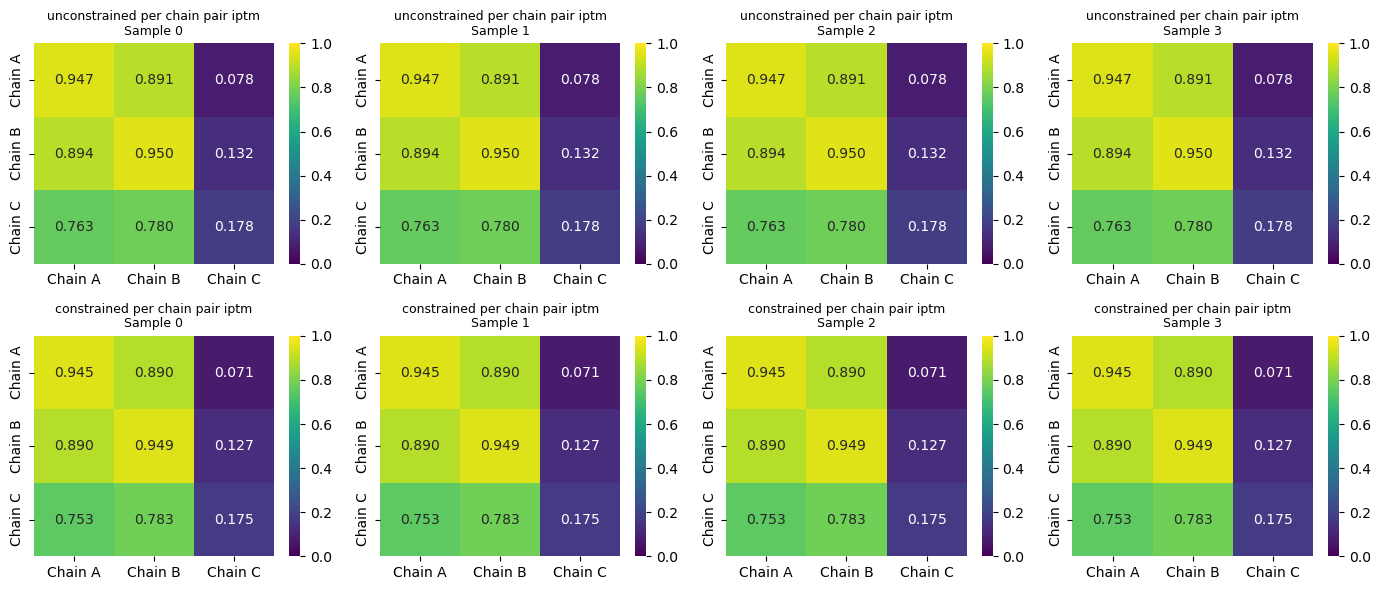

In [ ]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
def extract_matrix_min(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # germinal/mcmahon: only one interface (A-C or B-C)
    if n == 2:
        return np.min([matrix[0, 1], matrix[1, 0]])

    # snir: average C interactions with A and B
    elif n == 3:
        ac = np.min([matrix[0, 2], matrix[2, 0]])
        bc = np.min([matrix[1, 2], matrix[2, 1]])
        return np.min([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_pair_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)

chai_df['chai_constrained_per_chain_pair_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)


# Display summary
print("Unconstrained A-B interface min (top 10):")
print(chai_df['chai_unconstrained_per_chain_pair_iptm'].head(10).to_string())
print("\nConstrained A-B interface min (top 10):")
print(chai_df['chai_constrained_per_chain_pair_iptm'].head(10).to_string())

Unconstrained A-B interface min (top 10):
0    0.077992
1    0.077992
2    0.077992
3    0.077992
4    0.077992
5    0.077992
6    0.073652
7    0.073652
8    0.073652
9    0.073652

Constrained A-B interface min (top 10):
0    0.071191
1    0.071191
2    0.071191
3    0.071191
4    0.071191
5    0.071191
6    0.071804
7    0.071804
8    0.071804
9    0.071804


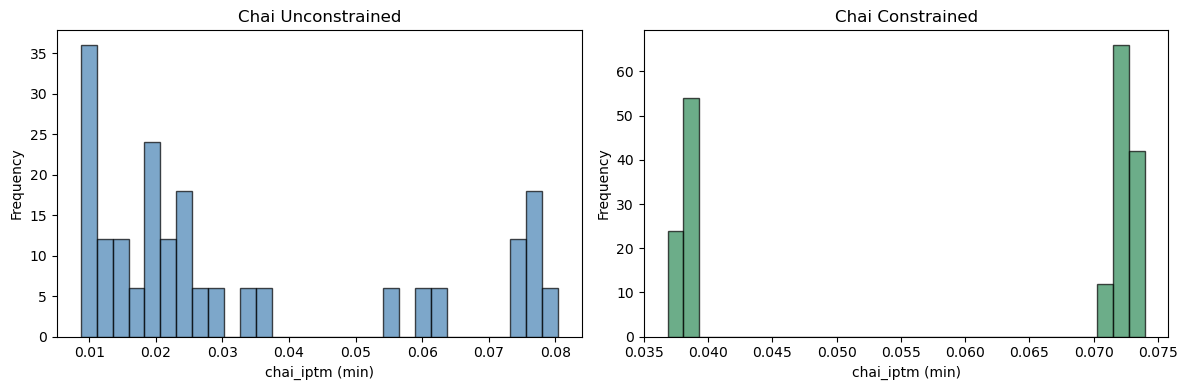

In [ ]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_iptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Extract min pTM
def extract_ptm_min(arr):
    """Extract minimum of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.min(arr)

# Extract min for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Extract min for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Display summary

print("\nUnconstrained pTM min (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM min (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM min - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM min - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")


Unconstrained pTM min (top 10):
0    0.178244
1    0.178244
2    0.178244
3    0.178244
4    0.178244
5    0.178244
6    0.175888
7    0.175888
8    0.175888
9    0.175888

Constrained pTM min (top 10):
0    0.175172
1    0.175172
2    0.175172
3    0.175172
4    0.175172
5    0.175172
6    0.175865
7    0.175865
8    0.175865
9    0.175865

Unconstrained pTM min - desc stats:
count    198.000000
mean       0.117962
std        0.033743
min        0.088425
25%        0.094462
50%        0.098414
75%        0.160372
max        0.178802
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM min - desc stats:
count    198.000000
mean       0.160163
std        0.019690
min        0.132804
25%        0.136235
50%        0.174867
75%        0.176241
max        0.178860
Name: chai_constrained_per_chain_ptm, dtype: float64


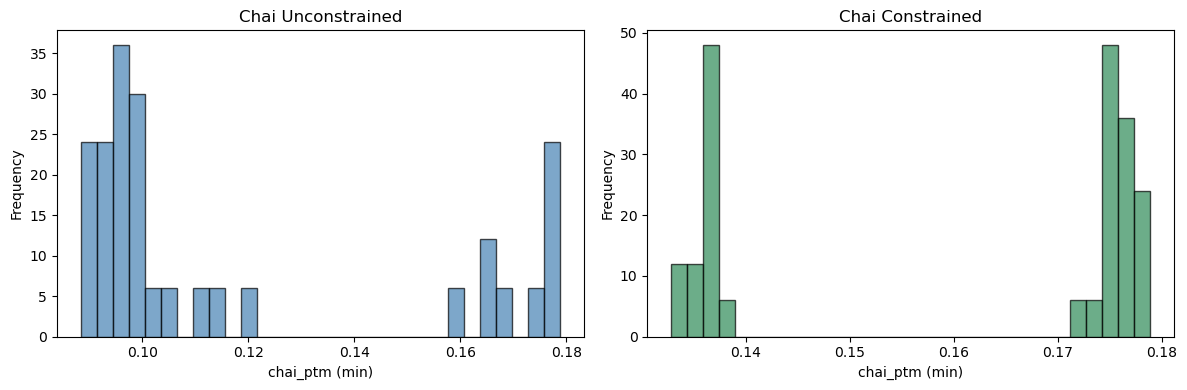

In [ ]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_ptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_ptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_pair_iptm',
                            'chai_constrained_per_chain_pair_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (198, 5)

df_chai_numeric head:
         sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                              0.071191
1  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                              0.071191
2  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                              0.071191
3  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                              0.071191
4  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                        

In [ ]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,source,type,sample,fab,binder,KD[M],interface_y,af3_pae,af3_plddt,af3_interface_dG,...,chai_unconstrained_mpnn_nll_a,chai_unconstrained_mpnn_nll_b,esmfold_esm3dg_dg,esmfold_esm3dg_dg_a,esmfold_esm3dg_dg_b,esmfold_esm3dg_dg_std,esmfold_mpnn_confidence,esmfold_mpnn_nll,esmfold_mpnn_nll_a,esmfold_mpnn_nll_b
0,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,B",2.593883,95.404666,55.85,...,1.067877,1.252996,5.089642,4.622507,5.556777,0.159190,0.268890,1.313454,1.302920,1.323989
1,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,C",2.593883,95.404666,16.50,...,1.067877,1.463277,3.275588,4.622507,1.928668,0.272223,0.149689,1.899199,1.302920,2.495477
2,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"B,C",2.593883,95.404666,12.88,...,1.252996,1.463277,3.742723,5.556777,1.928668,0.223455,0.148120,1.909733,1.323989,2.495477
3,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,B",2.593883,95.404666,55.85,...,1.067877,1.252996,5.089642,4.622507,5.556777,0.159190,0.268890,1.313454,1.302920,1.323989
4,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,C",2.593883,95.404666,16.50,...,1.067877,1.463277,3.275588,4.622507,1.928668,0.272223,0.149689,1.899199,1.302920,2.495477


In [ ]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (1188, 138)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

scores_df_extended head:
         sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                              0.071191
1  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                              0.071191
2  5ifj_abc_cut                          0.178244                        0.175172                                0.077992                              0.071191
3  5ifj_abc_cut                          0.178244                        0.175172                       

In [ ]:
scores_df_extended.head()

,source,type,sample,fab,binder,KD[M],interface_y,af3_pae,af3_plddt,af3_interface_dG,...,esmfold_esm3dg_dg_b,esmfold_esm3dg_dg_std,esmfold_mpnn_confidence,esmfold_mpnn_nll,esmfold_mpnn_nll_a,esmfold_mpnn_nll_b,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm
0,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,B",2.593883,95.404666,55.85,...,5.556777,0.15919,0.26889,1.313454,1.30292,1.323989,0.178244,0.175172,0.077992,0.071191
1,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,B",2.593883,95.404666,55.85,...,5.556777,0.15919,0.26889,1.313454,1.30292,1.323989,0.178244,0.175172,0.077992,0.071191
2,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,B",2.593883,95.404666,55.85,...,5.556777,0.15919,0.26889,1.313454,1.30292,1.323989,0.178244,0.175172,0.077992,0.071191
3,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,B",2.593883,95.404666,55.85,...,5.556777,0.15919,0.26889,1.313454,1.30292,1.323989,0.178244,0.175172,0.077992,0.071191
4,snir_ab,original,5ifj_abc_cut,1000.0,1,0.00001,"A,B",2.593883,95.404666,55.85,...,5.556777,0.15919,0.26889,1.313454,1.30292,1.323989,0.178244,0.175172,0.077992,0.071191
